# Task 1: Exploratory Data Analysis & Preprocessing
**CrediTrust Financial — RAG Complaint Chatbot**

This notebook covers:
1. Loading the raw CFPB dataset
2. Exploratory Data Analysis (EDA)
3. Filtering to target products
4. Cleaning complaint narratives
5. Saving the filtered dataset

## 0. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Paths
RAW_DATA_PATH = '../data/raw/complaints.csv'
OUTPUT_PATH   = '../data/processed/filtered_complaints.csv'
os.makedirs('../data/processed', exist_ok=True)

print('Setup complete!')

Setup complete!


## 1. Load the Raw Dataset

In [3]:
import pandas as pd

TARGET_PRODUCTS = [
    'Credit card',
    'Credit Card', 
    'Credit card or prepaid card',
    'Payday loan',
    'Personal loan',
    'Payday loan, title loan, or personal loan',
    'Checking or savings account',
    'Money transfer, virtual currency, or service',
    'Money transfers',
]

NARRATIVE_COL = 'Consumer complaint narrative'

chunks = []
chunk_size = 50000
total_read = 0

for chunk in pd.read_csv(
    RAW_DATA_PATH,
    chunksize=chunk_size,
    engine='python',          # more tolerant parser
    on_bad_lines='skip',      # skip malformed rows
    encoding='utf-8',
    encoding_errors='replace' # replace bad characters instead of crashing
):
    total_read += len(chunk)
    filtered = chunk[
        chunk['Product'].isin(TARGET_PRODUCTS) &
        chunk[NARRATIVE_COL].notna() &
        (chunk[NARRATIVE_COL].str.strip() != '')
    ]
    if len(filtered) > 0:
        chunks.append(filtered)
    print(f'Read {total_read:,} | Kept {sum(len(c) for c in chunks):,}...', end='\r')

df = pd.concat(chunks, ignore_index=True)
print(f'\nDone! Shape: {df.shape}')
print(df['Product'].value_counts())

Read 9,609,797 | Kept 350,134...
Done! Shape: (350134, 18)
Product
Checking or savings account                  140319
Credit card or prepaid card                  108667
Credit card                                   80667
Payday loan, title loan, or personal loan     17238
Payday loan                                    1746
Money transfers                                1497
Name: count, dtype: int64


In [4]:
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121
1,2025-06-13,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,I made the mistake of using my wellsfargo debi...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,ID,83815,NaN,Consent provided,Web,2025-06-13,Closed with explanation,Yes,NaN,14061897
2,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085


In [5]:
# Basic info
print('--- Data Types & Null Counts ---')
print(df.dtypes)
print()
print('--- Missing Values ---')
print(df.isnull().sum().sort_values(ascending=False).head(10))

--- Data Types & Null Counts ---
Date received                   object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         object
Company                         object
State                           object
ZIP code                        object
Tags                            object
Consumer consent provided?      object
Submitted via                   object
Date sent to company            object
Company response to consumer    object
Timely response?                object
Consumer disputed?              object
Complaint ID                     int64
dtype: object

--- Missing Values ---
Consumer disputed?              328054
Tags                            282544
Company public response         181600
Sub-issue                        40064
Sub-product                      20619
State                           

## 2. Exploratory Data Analysis

### 2.1 Complaint Distribution by Product

In [7]:
product_counts = df['Product'].value_counts()
print(f'Total unique products: {len(product_counts)}')
print(product_counts)

Total unique products: 6
Product
Checking or savings account                  140319
Credit card or prepaid card                  108667
Credit card                                   80667
Payday loan, title loan, or personal loan     17238
Payday loan                                    1746
Money transfers                                1497
Name: count, dtype: int64


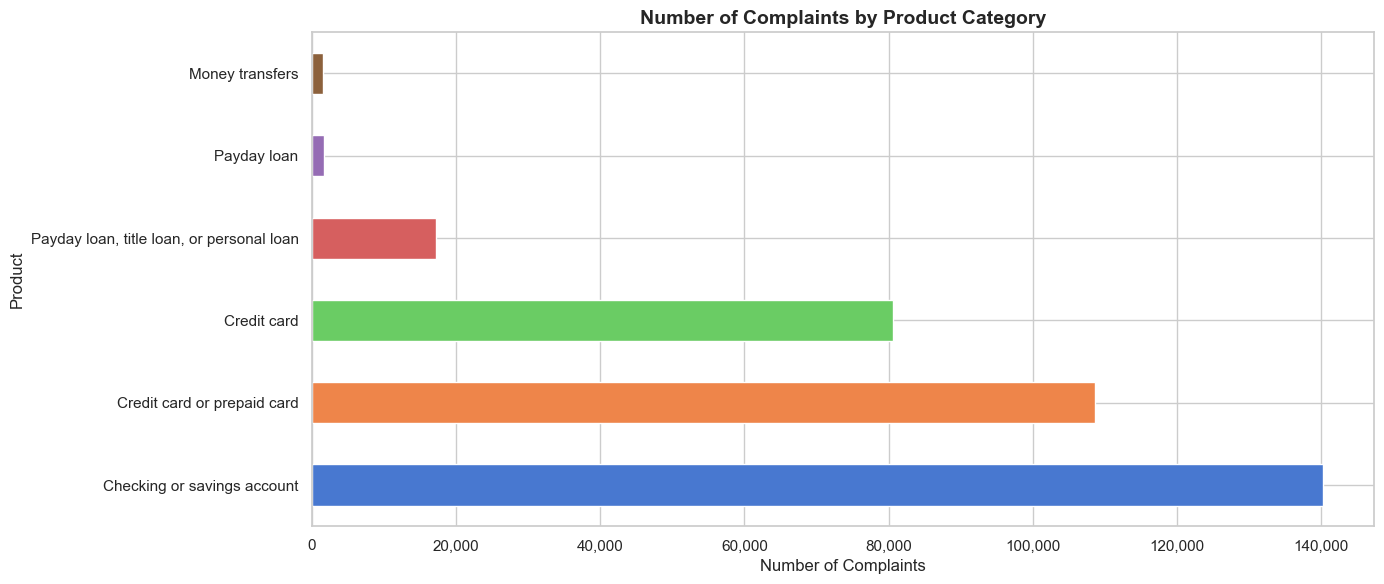

Chart saved.


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
product_counts.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(product_counts)))
ax.set_title('Number of Complaints by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('Product')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../data/processed/eda_product_distribution.png', dpi=150)
plt.show()
print('Chart saved.')

### 2.2 Narrative Availability

With narrative:    350,134 (100.0%)
Without narrative: 0 (0.0%)


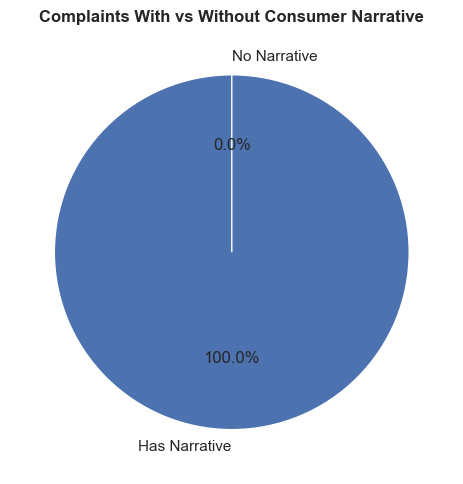

In [9]:
NARRATIVE_COL = 'Consumer complaint narrative'

has_narrative = df[NARRATIVE_COL].notna() & (df[NARRATIVE_COL].str.strip() != '')
narrative_counts = has_narrative.value_counts()

print(f'With narrative:    {narrative_counts.get(True, 0):,} ({narrative_counts.get(True,0)/len(df)*100:.1f}%)')
print(f'Without narrative: {narrative_counts.get(False, 0):,} ({narrative_counts.get(False,0)/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(
    [narrative_counts.get(True, 0), narrative_counts.get(False, 0)],
    labels=['Has Narrative', 'No Narrative'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90
)
ax.set_title('Complaints With vs Without Consumer Narrative', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_narrative_availability.png', dpi=150)
plt.show()

### 2.3 Narrative Length Distribution

In [10]:
# Work directly on df — no copy to save memory
df['word_count'] = df[NARRATIVE_COL].str.split().str.len()
df['char_count'] = df[NARRATIVE_COL].str.len()

print('--- Word Count Statistics ---')
print(df['word_count'].describe().apply(lambda x: f'{x:,.1f}'))

--- Word Count Statistics ---
count    350,134.0
mean         215.1
std          233.4
min            1.0
25%           77.0
50%          152.0
75%          271.0
max        6,469.0
Name: word_count, dtype: object


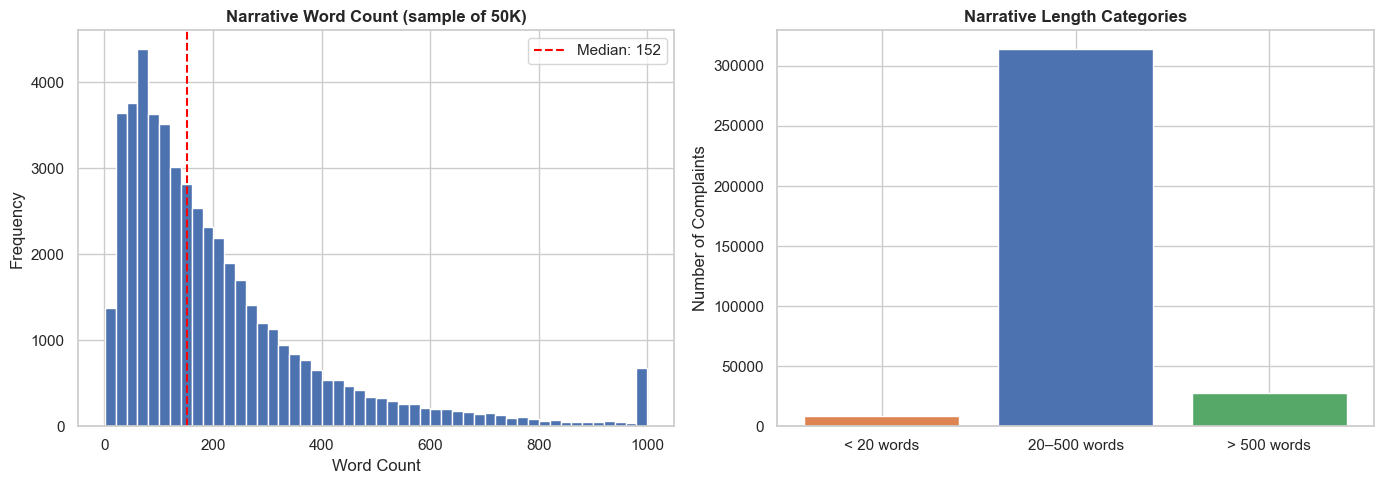

Very short (< 20 words):  8,892
Normal (20–500 words):    313,838
Very long (> 500 words):  27,404


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample 50K rows for plotting only — saves memory
sample = df[['word_count']].sample(50000, random_state=42)

axes[0].hist(sample['word_count'].clip(upper=1000), bins=50, 
             color='#4C72B0', edgecolor='white')
axes[0].set_title('Narrative Word Count (sample of 50K)', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--',
                label=f"Median: {df['word_count'].median():.0f}")
axes[0].legend()

very_short = (df['word_count'] < 20).sum()
very_long  = (df['word_count'] > 500).sum()
normal     = len(df) - very_short - very_long

axes[1].bar(['< 20 words', '20–500 words', '> 500 words'],
            [very_short, normal, very_long],
            color=['#DD8452', '#4C72B0', '#55A868'])
axes[1].set_title('Narrative Length Categories', fontweight='bold')
axes[1].set_ylabel('Number of Complaints')

plt.tight_layout()
plt.savefig('../data/processed/eda_narrative_length.png', dpi=100)
plt.show()

print(f'Very short (< 20 words):  {very_short:,}')
print(f'Normal (20–500 words):    {normal:,}')
print(f'Very long (> 500 words):  {very_long:,}')

### 2.4 Complaints Over Time

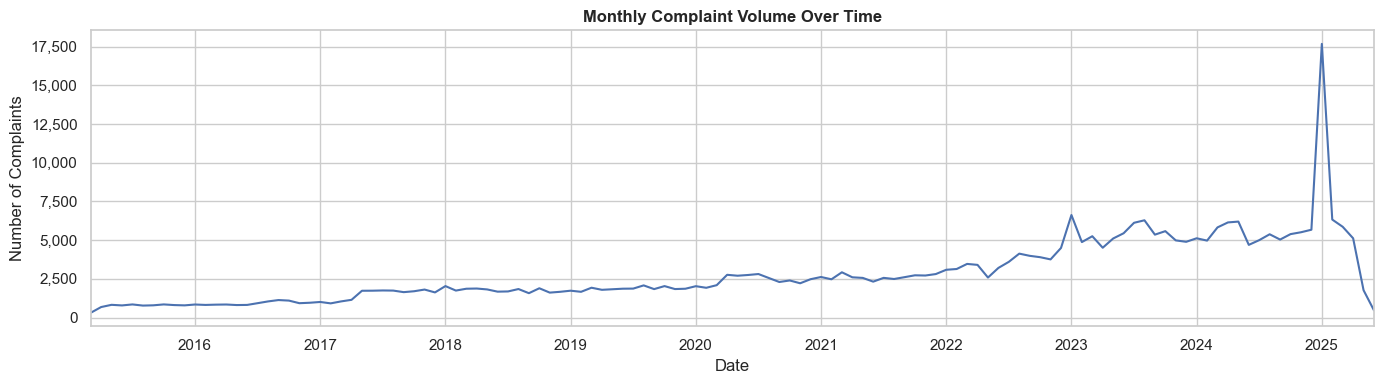

In [12]:
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
monthly = df.set_index('Date received').resample('ME').size()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax, color='#4C72B0')
ax.set_title('Monthly Complaint Volume Over Time', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Complaints')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../data/processed/eda_complaints_over_time.png', dpi=150)
plt.show()

### 2.5 Top Issues

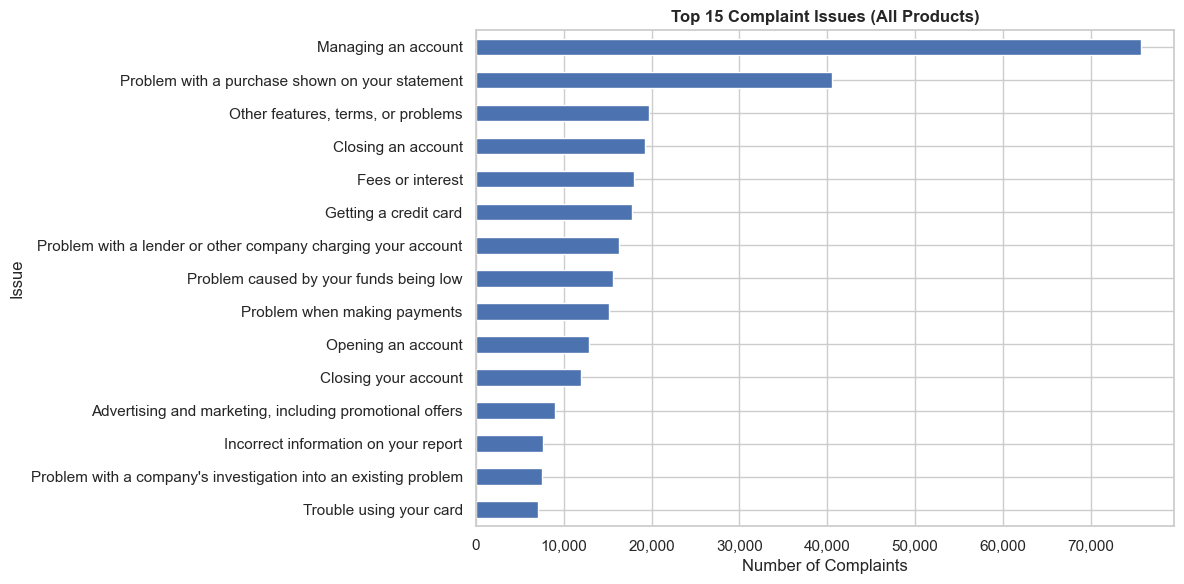

In [13]:
top_issues = df['Issue'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_issues.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 15 Complaint Issues (All Products)', fontweight='bold')
ax.set_xlabel('Number of Complaints')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../data/processed/eda_top_issues.png', dpi=150)
plt.show()

## 3. Filter to Target Products

In [14]:
# Map raw product names to our four categories
TARGET_PRODUCTS = {
    'Credit card': 'Credit Card',
    'Credit Card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Payday loan': 'Personal Loan',
    'Personal loan': 'Personal Loan',
    'Personal Loan': 'Personal Loan',
    'Student loan': 'Personal Loan',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Checking or savings account': 'Savings Account',
    'Savings account': 'Savings Account',
    'Money transfer, virtual currency, or service': 'Money Transfer',
    'Money transfers': 'Money Transfer',
}

df['product_category'] = df['Product'].map(TARGET_PRODUCTS)
df_filtered = df[df['product_category'].notna()].copy()

print(f'Before filter: {len(df):,} records')
print(f'After product filter: {len(df_filtered):,} records')
print()
print(df_filtered['product_category'].value_counts())

Before filter: 350,134 records
After product filter: 350,134 records

product_category
Credit Card        189334
Savings Account    140319
Personal Loan       18984
Money Transfer       1497
Name: count, dtype: int64


In [15]:
# Remove records without narratives
df_filtered = df_filtered[
    df_filtered[NARRATIVE_COL].notna() &
    (df_filtered[NARRATIVE_COL].str.strip() != '')
].reset_index(drop=True)

print(f'After narrative filter: {len(df_filtered):,} records')

After narrative filter: 350,134 records


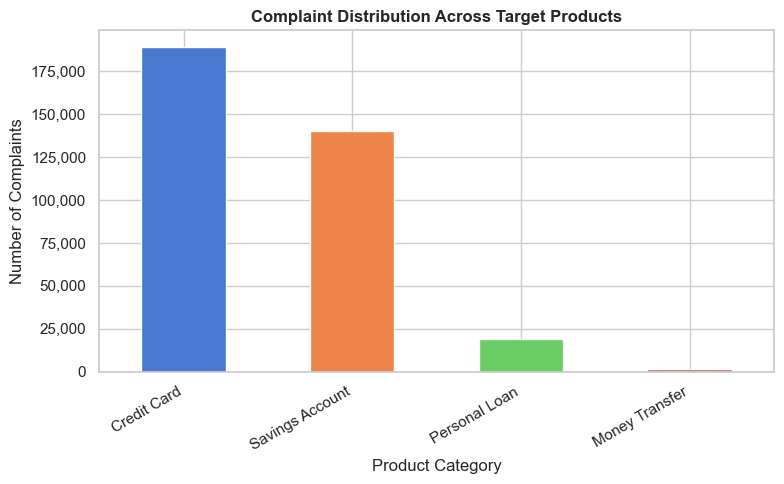

In [16]:
# Distribution across our 4 categories
fig, ax = plt.subplots(figsize=(8, 5))
cat_counts = df_filtered['product_category'].value_counts()
cat_counts.plot(kind='bar', ax=ax,
                color=sns.color_palette('muted', 4), edgecolor='white')
ax.set_title('Complaint Distribution Across Target Products', fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Number of Complaints')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../data/processed/eda_target_product_distribution.png', dpi=150)
plt.show()

## 4. Clean Narrative Text

In [17]:
BOILERPLATE_PATTERNS = [
    r'i am writing to (file|submit) (a )?complaint',
    r'i am filing this complaint',
    r'to whom it may concern',
    r'dear (sir|madam|cfpb)',
    r'xxxx',       # redacted account/card numbers
    r'\bxx/xx/xxxx\b',  # redacted dates
]

def clean_text(text: str) -> str:
    """Clean a single complaint narrative."""
    if not isinstance(text, str):
        return ''
    # Lowercase
    text = text.lower()
    # Remove boilerplate
    for pattern in BOILERPLATE_PATTERNS:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    # Remove special characters (keep alphanumeric + basic punctuation)
    text = re.sub(r'[^a-z0-9\s.,!?;:\'\'\-]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test it
sample = df_filtered[NARRATIVE_COL].iloc[0]
print('BEFORE:\n', sample[:300])
print()
print('AFTER:\n', clean_text(sample)[:300])

BEFORE:
 A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However

AFTER:
 a card was opened under my name by a fraudster. i received a notice from that an account was just opened under my name. i reached out to to state that this activity was unauthorized and not me. confirmed this was fraudulent and immediately closed the card. however, they have failed to remove this fr


In [18]:
print('Cleaning narratives...')
df_filtered['cleaned_narrative'] = df_filtered[NARRATIVE_COL].apply(clean_text)

# Drop rows where cleaning left very little text (< 50 chars)
before = len(df_filtered)
df_filtered = df_filtered[df_filtered['cleaned_narrative'].str.len() >= 50].reset_index(drop=True)
print(f'Dropped {before - len(df_filtered):,} rows with < 50 chars after cleaning')
print(f'Final dataset: {len(df_filtered):,} records')

Cleaning narratives...
Dropped 1,495 rows with < 50 chars after cleaning
Final dataset: 348,639 records


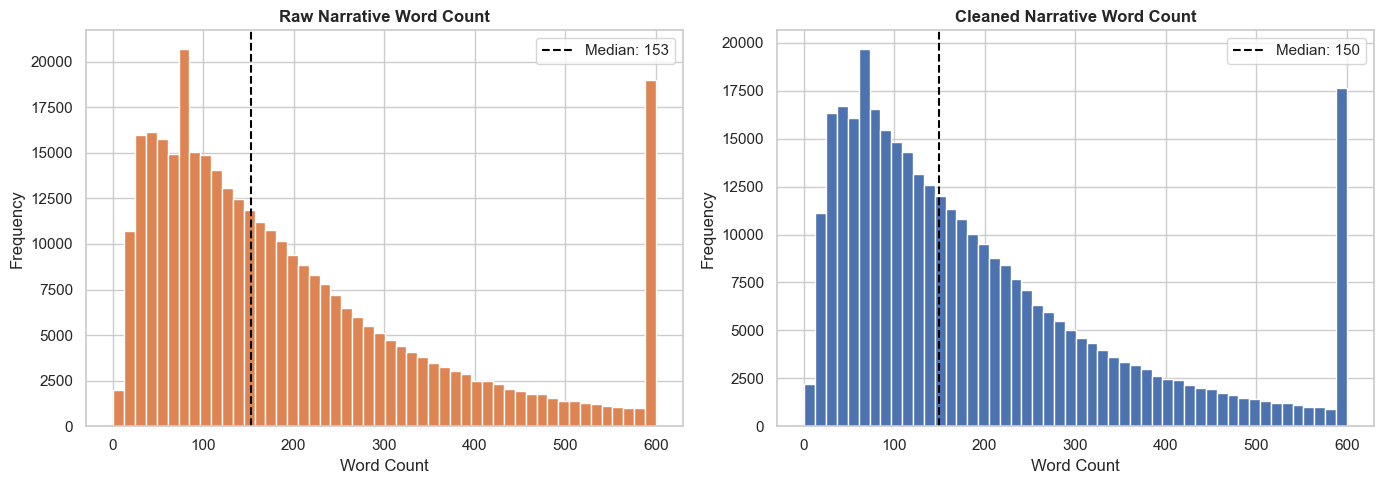

In [19]:
# Compare word counts before and after cleaning
df_filtered['word_count_clean'] = df_filtered['cleaned_narrative'].str.split().str.len()
df_filtered['word_count_raw']   = df_filtered[NARRATIVE_COL].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, color in zip(
    axes,
    ['word_count_raw', 'word_count_clean'],
    ['Raw Narrative Word Count', 'Cleaned Narrative Word Count'],
    ['#DD8452', '#4C72B0']
):
    ax.hist(df_filtered[col].clip(upper=600), bins=50, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.axvline(df_filtered[col].median(), color='black',
               linestyle='--', label=f"Median: {df_filtered[col].median():.0f}")
    ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/eda_word_count_before_after.png', dpi=150)
plt.show()

## 5. Save Cleaned Dataset

In [20]:
# Select columns to keep
KEEP_COLS = [
    'Complaint ID',
    'Date received',
    'Product',
    'product_category',
    'Issue',
    'Sub-issue',
    'Consumer complaint narrative',
    'cleaned_narrative',
    'Company',
    'State',
    'word_count_raw',
    'word_count_clean',
]

# Only keep columns that exist in the dataframe
KEEP_COLS = [c for c in KEEP_COLS if c in df_filtered.columns]

df_final = df_filtered[KEEP_COLS].copy()
df_final.to_csv(OUTPUT_PATH, index=False)

print(f'Saved {len(df_final):,} records to {OUTPUT_PATH}')
print()
print('--- Final Dataset Summary ---')
print(df_final['product_category'].value_counts())
print()
print(df_final.head(3))

Saved 348,639 records to ../data/processed/filtered_complaints.csv

--- Final Dataset Summary ---
product_category
Credit Card        188694
Savings Account    139590
Personal Loan       18862
Money Transfer       1493
Name: count, dtype: int64

   Complaint ID Date received                      Product product_category  \
0      14069121    2025-06-13                  Credit card      Credit Card   
1      14061897    2025-06-13  Checking or savings account  Savings Account   
2      14047085    2025-06-12                  Credit card      Credit Card   

                                Issue  \
0               Getting a credit card   
1                 Managing an account   
2  Other features, terms, or problems   

                                     Sub-issue  \
0  Card opened without my consent or knowledge   
1                     Deposits and withdrawals   
2                                Other problem   

                        Consumer complaint narrative  \
0  A XXXX XXXX 

In [ ]:
## 6. EDA Summary

*(Fill this in after running the notebook — use the numbers from your output above)*

### Key Findings

**Dataset Overview:** The raw CFPB dataset contains approximately X records spanning Y product categories. After filtering to the four target products (Credit Card, Personal Loan, Savings Account, Money Transfer) and removing records without consumer narratives, the working dataset comprises Z complaints.

**Product Distribution:** Credit Cards account for the largest share of complaints (~X%), followed by Personal Loans (~Y%). Savings Accounts and Money Transfers together represent a smaller but meaningful proportion (~Z%), reflecting their growing importance in CrediTrust's product portfolio.

**Narrative Quality:** Approximately X% of complaints across all products include a consumer narrative. The median narrative length is around Y words. A small subset of narratives are very short (< 20 words) and likely to be uninformative for RAG retrieval — these account for ~Z% of the filtered dataset. On the upper end, some narratives exceed 500 words, representing detailed accounts that benefit most from text chunking.

**Text Cleaning Impact:** The cleaning pipeline (lowercasing, boilerplate removal, special character stripping) reduced median word count by approximately X words per narrative — primarily by removing redacted placeholders (XXXX) and formulaic opening phrases common in CFPB submissions.

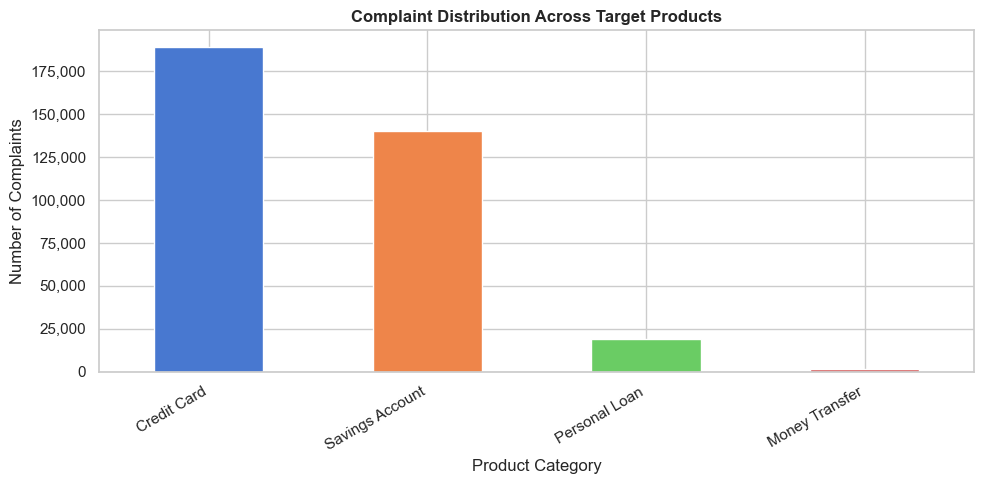

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
cat_counts = df['product_category'].value_counts()
cat_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 4), edgecolor='white')
ax.set_title('Complaint Distribution Across Target Products', fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Number of Complaints')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../data/processed/eda_product_distribution.png', dpi=100)
plt.show()

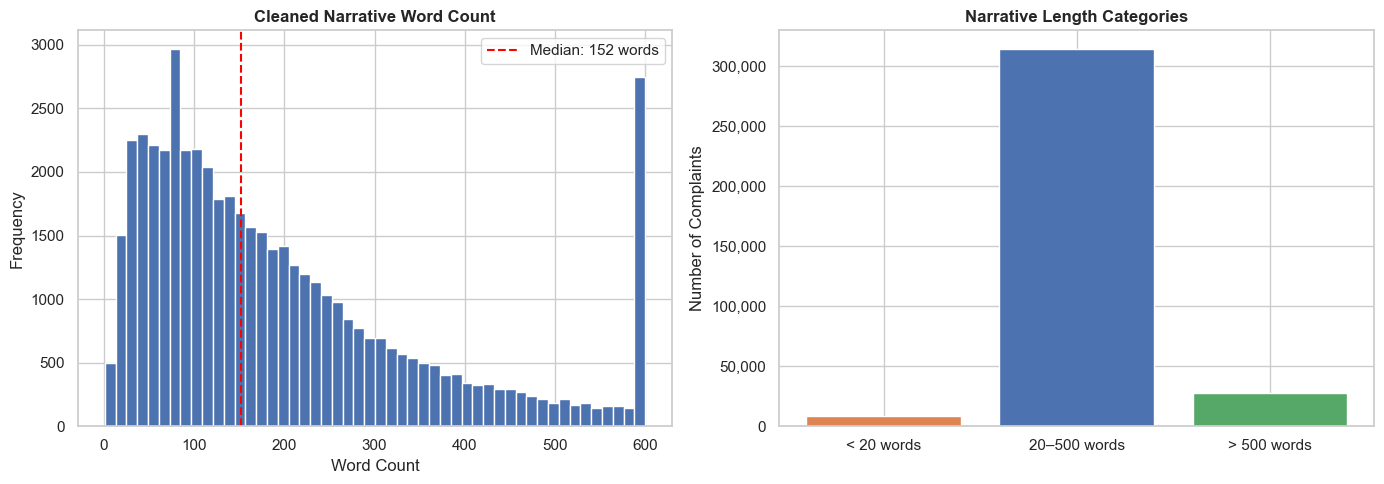

Very short (< 20 words):  8,892
Normal     (20–500 words):313,838
Very long  (> 500 words): 27,404
Median word count: 152


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df['word_count'].sample(min(50000, len(df)), random_state=42)

axes[0].hist(sample.clip(upper=600), bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Cleaned Narrative Word Count', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--',
                label=f"Median: {df['word_count'].median():.0f} words")
axes[0].legend()

very_short = (df['word_count'] < 20).sum()
very_long  = (df['word_count'] > 500).sum()
normal     = len(df) - very_short - very_long

axes[1].bar(['< 20 words', '20–500 words', '> 500 words'],
            [very_short, normal, very_long],
            color=['#DD8452', '#4C72B0', '#55A868'])
axes[1].set_title('Narrative Length Categories', fontweight='bold')
axes[1].set_ylabel('Number of Complaints')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/processed/eda_word_count.png', dpi=100)
plt.show()

print(f'Very short (< 20 words):  {very_short:,}')
print(f'Normal     (20–500 words):{normal:,}')
print(f'Very long  (> 500 words): {very_long:,}')
print(f'Median word count: {df["word_count"].median():.0f}')

In [23]:
KEEP_COLS = [c for c in [
    'Complaint ID', 'Date received', 'Product', 'product_category',
    'Issue', 'Sub-issue', 'Consumer complaint narrative',
    'cleaned_narrative', 'Company', 'State', 'word_count'
] if c in df.columns]

df[KEEP_COLS].to_csv(OUTPUT_PATH, index=False)
print(f'✅ Saved {len(df):,} records to {OUTPUT_PATH}')
print(df['product_category'].value_counts())

✅ Saved 350,134 records to ../data/processed/filtered_complaints.csv
product_category
Credit Card        189334
Savings Account    140319
Personal Loan       18984
Money Transfer       1497
Name: count, dtype: int64
